In [1]:
!pip install timm -q

## Test Branch push

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                         GLOBAL CONFIGURATION                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import os
import random
import numpy as np
import torch

# ── Dataset Path (MANDATORY - DO NOT CHANGE) ───────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/sabuktagin/tropical-flowers/Tropical Flower Dataset Seven Species from Bangladesh for Classification and Ecological Research/Flower Dataset/Flower Dataset'
OUTPUT_DIR = '/kaggle/working'

# ── Training Hyperparameters ───────────────────────────────────────────────────
BATCH_SIZE = 32
NUM_EPOCHS = 1
SEED = 42

# ── Optimizer Settings ─────────────────────────────────────────────────────────
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

# ── Early Stopping ─────────────────────────────────────────────────────────────
EARLY_STOP_PATIENCE = 5

# ── Image Settings ─────────────────────────────────────────────────────────────
IMG_SIZE = 224
NUM_CLASSES = 7

# ── ImageNet Normalization Stats ───────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ── Class Names ────────────────────────────────────────────────────────────────
CLASS_NAMES = ['Bougainvillea', 'Crown of thorns', 'Hibiscus', 'Jungle geranium', 
               'Madagascar periwinkle', 'Marigold', 'Rose']

# ── Reproducibility Function ───────────────────────────────────────────────────
def seed_everything(seed=42):
    """Ensures full reproducibility across Python, NumPy, and PyTorch."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# ── Device Configuration ───────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 70)
print("CONFIGURATION LOADED SUCCESSFULLY")
print("=" * 70)
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Image Size: {IMG_SIZE}")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Data Directory: {DATA_DIR}")
print("=" * 70)

CONFIGURATION LOADED SUCCESSFULLY
Device: cuda
GPU: Tesla P100-PCIE-16GB
Batch Size: 32
Epochs: 1
Image Size: 224
Number of Classes: 7
Data Directory: /kaggle/input/datasets/sabuktagin/tropical-flowers/Tropical Flower Dataset Seven Species from Bangladesh for Classification and Ecological Research/Flower Dataset/Flower Dataset


In [3]:
import time
import warnings
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torch.nn.functional as F
from torch.cuda.amp import autocast, GradScaler

from torchvision import transforms
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"Timm Version: {timm.__version__}")

PyTorch Version: 2.9.0+cu126
Timm Version: 1.0.24


In [4]:
class FlowerDataset(Dataset):
    """Custom Dataset for Tropical Flower Classification."""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


def load_dataset_paths(data_dir):
    """Load all image paths and labels from directory structure."""
    data_path = Path(data_dir)
    image_paths = []
    labels = []
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(CLASS_NAMES)}
    
    for class_name in CLASS_NAMES:
        class_dir = data_path / class_name
        if class_dir.exists():
            for img_file in class_dir.iterdir():
                if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                    image_paths.append(str(img_file))
                    labels.append(class_to_idx[class_name])
    
    return image_paths, labels, class_to_idx


# Load all data
all_image_paths, all_labels, class_to_idx = load_dataset_paths(DATA_DIR)
print(f"Total images found: {len(all_image_paths)}")
print(f"Class mapping: {class_to_idx}")

Total images found: 4319
Class mapping: {'Bougainvillea': 0, 'Crown of thorns': 1, 'Hibiscus': 2, 'Jungle geranium': 3, 'Madagascar periwinkle': 4, 'Marigold': 5, 'Rose': 6}


CLASS DISTRIBUTION
                Class  Count  Percentage
                 Rose    827       19.15
             Marigold    717       16.60
      Jungle geranium    698       16.16
      Crown of thorns    583       13.50
        Bougainvillea    580       13.43
             Hibiscus    548       12.69
Madagascar periwinkle    366        8.47

Total Images: 4319
Max Class Count: 827 (Rose)
Min Class Count: 366 (Madagascar periwinkle)
Imbalance Ratio (min/max): 0.4426


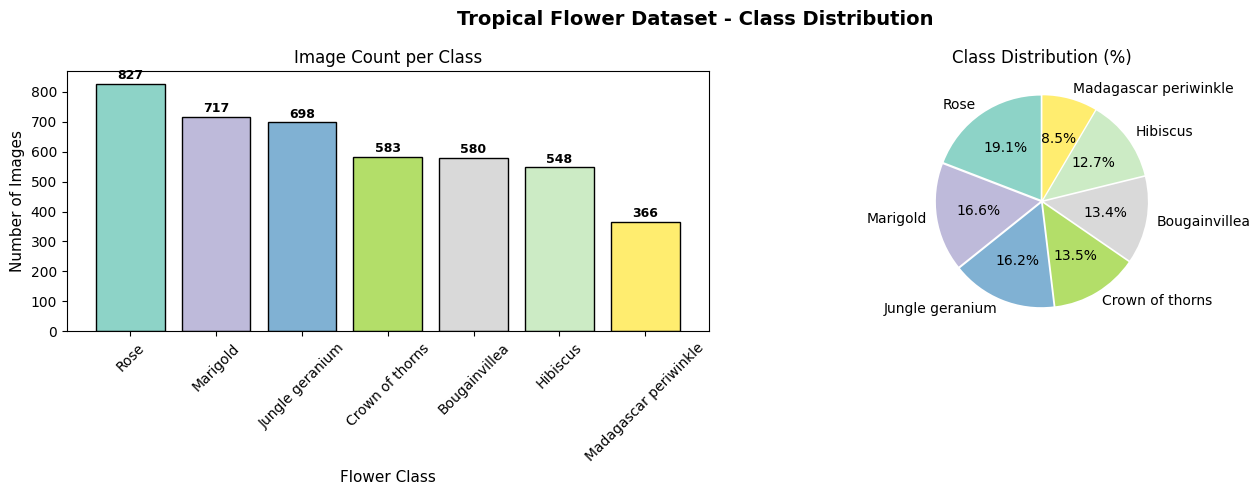


Per-Class Imbalance Ratios (relative to majority class):
--------------------------------------------------
Rose                      | Ratio: 1.0000 | Count: 827
Marigold                  | Ratio: 0.8670 | Count: 717
Jungle geranium           | Ratio: 0.8440 | Count: 698
Crown of thorns           | Ratio: 0.7050 | Count: 583
Bougainvillea             | Ratio: 0.7013 | Count: 580
Hibiscus                  | Ratio: 0.6626 | Count: 548
Madagascar periwinkle     | Ratio: 0.4426 | Count: 366


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                      EXPLORATORY DATA ANALYSIS                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Count images per class
label_counts = Counter(all_labels)
class_counts = {CLASS_NAMES[idx]: count for idx, count in sorted(label_counts.items())}

print("=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)

# Create DataFrame for analysis
eda_df = pd.DataFrame({
    'Class': list(class_counts.keys()),
    'Count': list(class_counts.values())
})
eda_df['Percentage'] = (eda_df['Count'] / eda_df['Count'].sum() * 100).round(2)
eda_df = eda_df.sort_values('Count', ascending=False).reset_index(drop=True)

print(eda_df.to_string(index=False))
print()

# Calculate imbalance metrics
max_count = eda_df['Count'].max()
min_count = eda_df['Count'].min()
imbalance_ratio = min_count / max_count

print(f"Total Images: {eda_df['Count'].sum()}")
print(f"Max Class Count: {max_count} ({eda_df.loc[eda_df['Count'].idxmax(), 'Class']})")
print(f"Min Class Count: {min_count} ({eda_df.loc[eda_df['Count'].idxmin(), 'Class']})")
print(f"Imbalance Ratio (min/max): {imbalance_ratio:.4f}")
print("=" * 70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tropical Flower Dataset - Class Distribution', fontsize=14, fontweight='bold')

# Bar plot
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = axes[0].bar(eda_df['Class'], eda_df['Count'], color=colors, edgecolor='black')
axes[0].set_xlabel('Flower Class', fontsize=11)
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_title('Image Count per Class', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, eda_df['Count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(eda_df['Count'], labels=eda_df['Class'], autopct='%1.1f%%', 
            colors=colors, startangle=90, explode=[0.02]*NUM_CLASSES)
axes[1].set_title('Class Distribution (%)', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratio per class
print("\nPer-Class Imbalance Ratios (relative to majority class):")
print("-" * 50)
for _, row in eda_df.iterrows():
    ratio = row['Count'] / max_count
    print(f"{row['Class']:<25} | Ratio: {ratio:.4f} | Count: {row['Count']}")

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    DATA PREPROCESSING & AUGMENTATION                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Training transforms with RandAugment (MANDATORY)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=9),  # REQUIRED
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation/Test transforms (STRICTLY DETERMINISTIC)
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Split data: 80% train, 10% val, 10% test
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=SEED, stratify=temp_labels
)

# Create datasets
train_dataset = FlowerDataset(train_paths, train_labels, transform=train_transform)
val_dataset = FlowerDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = FlowerDataset(test_paths, test_labels, transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=2, pin_memory=True)

print("=" * 70)
print("DATA SPLIT SUMMARY")
print("=" * 70)
print(f"Training set:   {len(train_dataset):>5} images ({len(train_dataset)/len(all_image_paths)*100:.1f}%)")
print(f"Validation set: {len(val_dataset):>5} images ({len(val_dataset)/len(all_image_paths)*100:.1f}%)")
print(f"Test set:       {len(test_dataset):>5} images ({len(test_dataset)/len(all_image_paths)*100:.1f}%)")
print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print("=" * 70)

DATA SPLIT SUMMARY
Training set:    3455 images (80.0%)
Validation set:   432 images (10.0%)
Test set:         432 images (10.0%)

Train batches: 107
Val batches:   14
Test batches:  14


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                      MODEL INITIALIZATION & HEAD ADAPTATION                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def count_parameters(model):
    """Count total trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def create_mobilenetv3_large(num_classes=7, pretrained=True):
    """Create MobileNetV3-Large with custom classifier head."""
    model = timm.create_model('mobilenetv3_large_100', pretrained=pretrained)
    
    # Get the input features of the classifier
    in_features = model.classifier.in_features
    
    # Replace classifier head for 7 classes
    model.classifier = nn.Linear(in_features, num_classes)
    
    return model


def create_resnext50_32x4d(num_classes=7, pretrained=True):
    """Create ResNeXt-50 (32x4d) with custom fc head."""
    model = timm.create_model('resnext50_32x4d', pretrained=pretrained)
    
    # Get the input features of the fc layer
    in_features = model.fc.in_features
    
    # Replace fc head for 7 classes
    model.fc = nn.Linear(in_features, num_classes)
    
    return model


def create_efficientnet_b3(num_classes=7, pretrained=True):
    """Create EfficientNet-B3 with custom classifier head."""
    model = timm.create_model('efficientnet_b3', pretrained=pretrained)
    
    # Get the input features of the classifier
    in_features = model.classifier.in_features
    
    # Replace classifier head for 7 classes
    model.classifier = nn.Linear(in_features, num_classes)
    
    return model


# Test model creation
print("=" * 70)
print("MODEL ARCHITECTURE VERIFICATION")
print("=" * 70)

test_models = {
    'MobileNetV3-Large': create_mobilenetv3_large,
    'ResNeXt-50-32x4d': create_resnext50_32x4d,
    'EfficientNet-B3': create_efficientnet_b3
}

for name, create_fn in test_models.items():
    model = create_fn(num_classes=NUM_CLASSES, pretrained=False)
    params = count_parameters(model)
    print(f"{name:<20} | Trainable Params: {params:>12,} ({params/1e6:.2f}M)")
    del model

print("=" * 70)

MODEL ARCHITECTURE VERIFICATION
MobileNetV3-Large    | Trainable Params:    4,210,999 (4.21M)
ResNeXt-50-32x4d     | Trainable Params:   22,994,247 (22.99M)
EfficientNet-B3      | Trainable Params:   10,706,991 (10.71M)


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    TRAINING INFRASTRUCTURE (MIXED PRECISION)                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

class EarlyStopping:
    """Early stopping handler with model checkpoint saving."""
    
    def __init__(self, patience=5, min_delta=0.0, path='best_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_val_loss = float('inf')
    
    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
    
    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.best_val_loss = val_loss


def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device):
    """Train for one epoch with mixed precision."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        # Scaled backward pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


@torch.no_grad()
def validate(model, val_loader, criterion, device):
    """Validate model on validation set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        running_loss += loss.item()
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_model(model, model_name, train_loader, val_loader, num_epochs=30, lr=1e-4, patience=5):
    """Full training loop with mixed precision, early stopping, and cosine annealing."""
    
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    scaler = GradScaler()
    
    checkpoint_path = f'{OUTPUT_DIR}/{model_name}_best.pth'
    early_stopping = EarlyStopping(patience=patience, path=checkpoint_path)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    print("\n" + "=" * 75)
    print(f" TRAINING: {model_name}")
    print("=" * 75)
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>10} | {'Val Acc':>9} | {'LR':>10}")
    print("-" * 75)
    
    best_val_acc = 0.0
    
    for epoch in range(1, num_epochs + 1):
        epoch_start = time.time()
        
        # Train
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, DEVICE
        )
        
        # Validate
        val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, DEVICE)
        
        # Update scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Check for best model
        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
        
        epoch_time = time.time() - epoch_start
        marker = " *" if is_best else ""
        
        print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
              f"{val_loss:>10.4f} | {val_acc:>8.2f}% | {current_lr:>10.2e}{marker}")
        
        # Early stopping check
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break
    
    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")
    print("=" * 75)
    
    return model, history, best_val_acc


def plot_training_history(history, model_name):
    """Plot training curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} - Training History', fontsize=14, fontweight='bold')
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(epochs, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], 'r-o', markersize=4, label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


print("Training infrastructure defined successfully.")

Training infrastructure defined successfully.


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

MobileNetV3-Large | Trainable Parameters: 4,210,999

 TRAINING: MobileNetV3_Large
 Epoch | Train Loss | Train Acc |   Val Loss |   Val Acc |         LR
---------------------------------------------------------------------------
     1 |     0.6333 |    84.38% |     0.0536 |    98.84% |   1.00e-06 *

Best Validation Accuracy: 98.84%


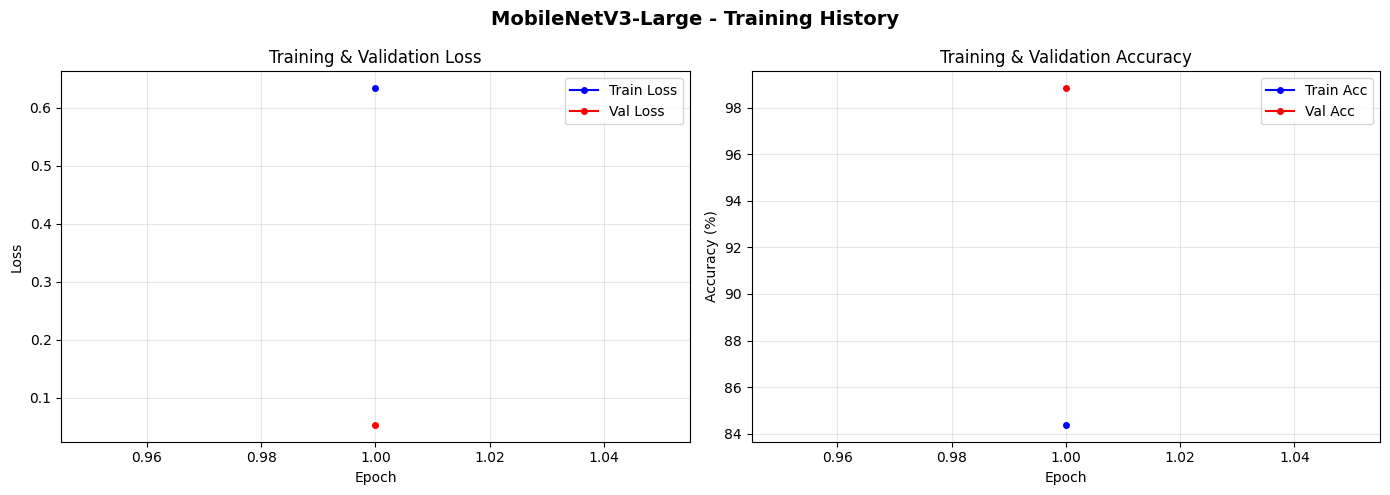

In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                         TRAIN MOBILENETV3-LARGE                              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

seed_everything(SEED)

mobilenet_v3 = create_mobilenetv3_large(num_classes=NUM_CLASSES, pretrained=True)
print(f"MobileNetV3-Large | Trainable Parameters: {count_parameters(mobilenet_v3):,}")

mobilenet_v3, history_mobilenet, best_acc_mobilenet = train_model(
    model=mobilenet_v3,
    model_name='MobileNetV3_Large',
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE
)

plot_training_history(history_mobilenet, 'MobileNetV3-Large')

model.safetensors:   0%|          | 0.00/100M [00:00<?, ?B/s]

ResNeXt-50-32x4d | Trainable Parameters: 22,994,247

 TRAINING: ResNeXt50_32x4d
 Epoch | Train Loss | Train Acc |   Val Loss |   Val Acc |         LR
---------------------------------------------------------------------------
     1 |     1.2402 |    67.46% |     0.1430 |    98.61% |   1.00e-06 *

Best Validation Accuracy: 98.61%


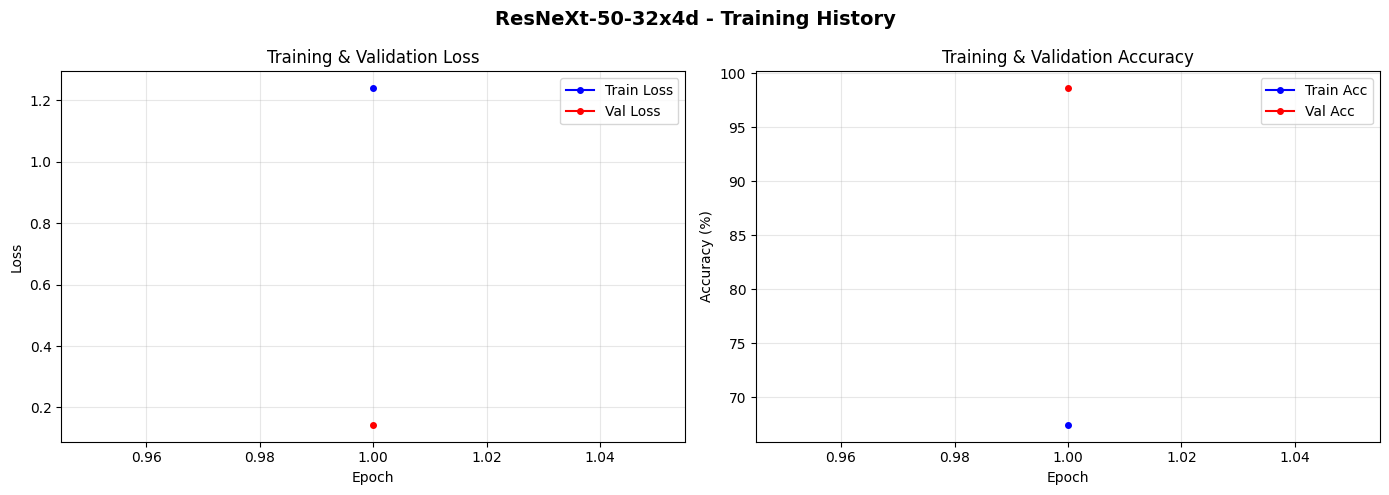

In [10]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                         TRAIN RESNEXT-50-32x4d                               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

seed_everything(SEED)

resnext50 = create_resnext50_32x4d(num_classes=NUM_CLASSES, pretrained=True)
print(f"ResNeXt-50-32x4d | Trainable Parameters: {count_parameters(resnext50):,}")

resnext50, history_resnext, best_acc_resnext = train_model(
    model=resnext50,
    model_name='ResNeXt50_32x4d',
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE
)

plot_training_history(history_resnext, 'ResNeXt-50-32x4d')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNet-B3 | Trainable Parameters: 10,706,991

 TRAINING: EfficientNet_B3
 Epoch | Train Loss | Train Acc |   Val Loss |   Val Acc |         LR
---------------------------------------------------------------------------
     1 |     0.6580 |    85.34% |     0.0667 |    99.31% |   1.00e-06 *

Best Validation Accuracy: 99.31%


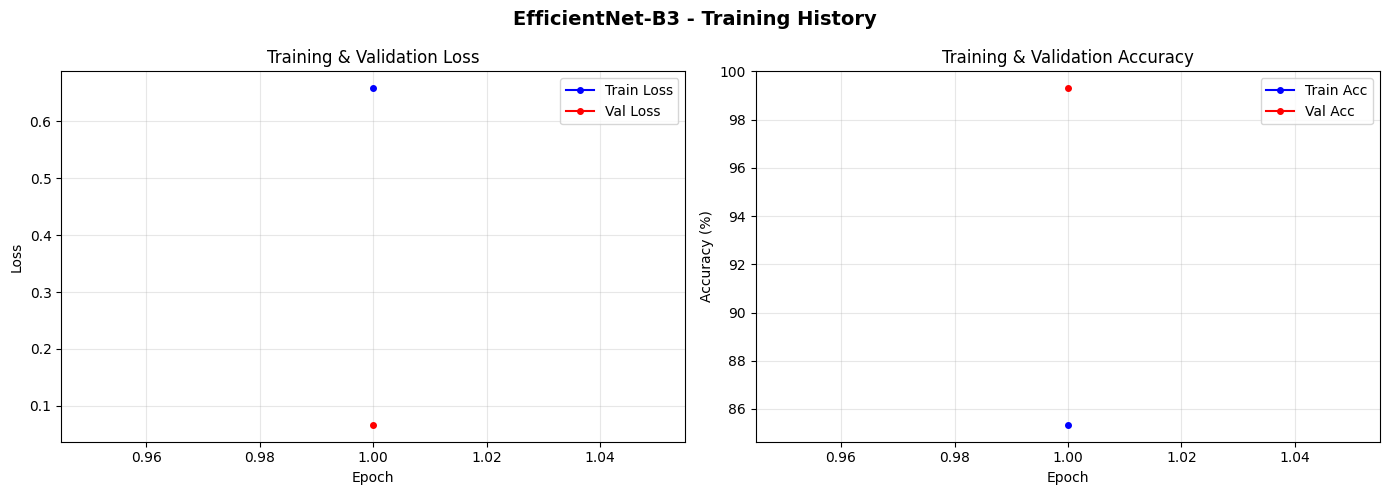

In [11]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                         TRAIN EFFICIENTNET-B3                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

seed_everything(SEED)

efficientnet_b3 = create_efficientnet_b3(num_classes=NUM_CLASSES, pretrained=True)
print(f"EfficientNet-B3 | Trainable Parameters: {count_parameters(efficientnet_b3):,}")

efficientnet_b3, history_effnet, best_acc_effnet = train_model(
    model=efficientnet_b3,
    model_name='EfficientNet_B3',
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    patience=EARLY_STOP_PATIENCE
)

plot_training_history(history_effnet, 'EfficientNet-B3')

TEST SET EVALUATION RESULTS

Evaluating: MobileNetV3-Large
  Accuracy:           99.07%
  Macro F1:           99.08%
  Weighted F1:        99.08%
  Macro Precision:    98.96%
  Weighted Precision: 99.09%
  Macro Recall:       99.21%
  Weighted Recall:    99.07%
  Inference Time:     14.85 ms/batch

Evaluating: ResNeXt-50-32x4d
  Accuracy:           98.84%
  Macro F1:           98.87%
  Weighted F1:        98.84%
  Macro Precision:    98.80%
  Weighted Precision: 98.85%
  Macro Recall:       98.96%
  Weighted Recall:    98.84%
  Inference Time:     68.46 ms/batch

Evaluating: EfficientNet-B3
  Accuracy:           99.07%
  Macro F1:           99.06%
  Weighted F1:        99.07%
  Macro Precision:    99.00%
  Weighted Precision: 99.08%
  Macro Recall:       99.14%
  Weighted Recall:    99.07%
  Inference Time:     47.83 ms/batch


SUMMARY TABLE
------------------------------------------------------------------------------------------
Model                |     Acc |    F1-M |    F1-W |  P

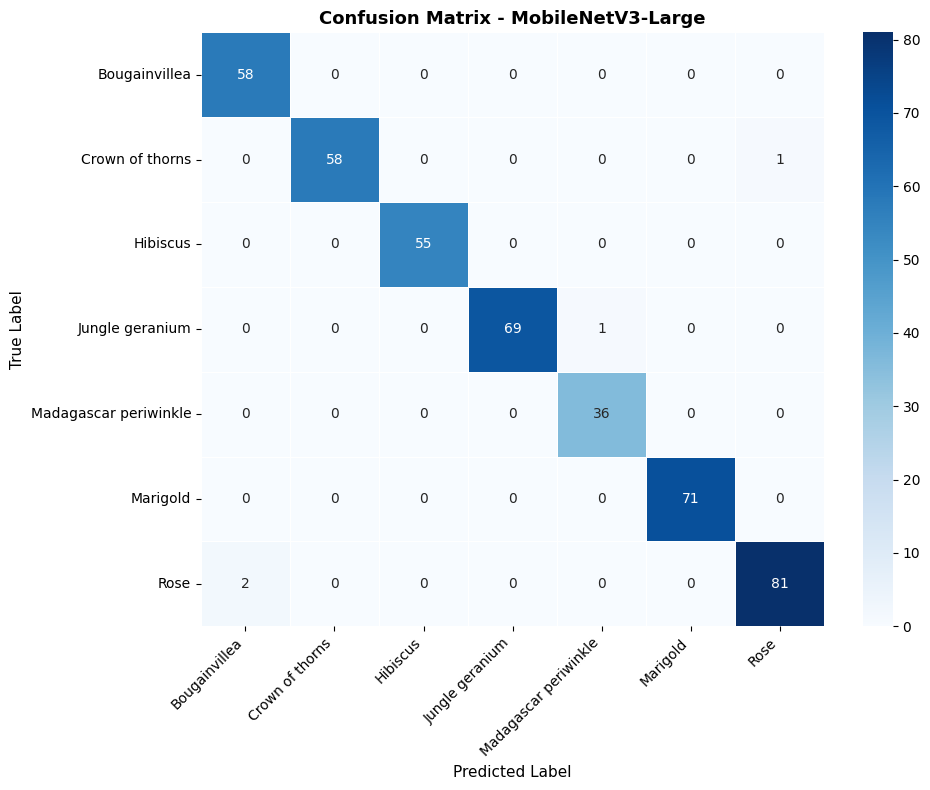

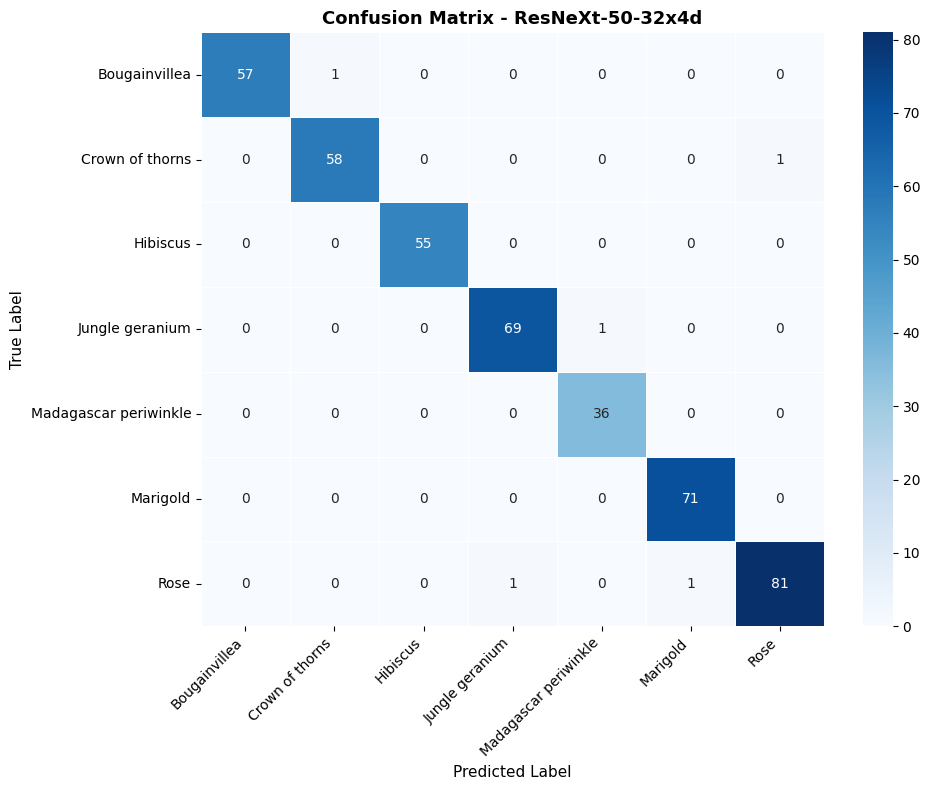

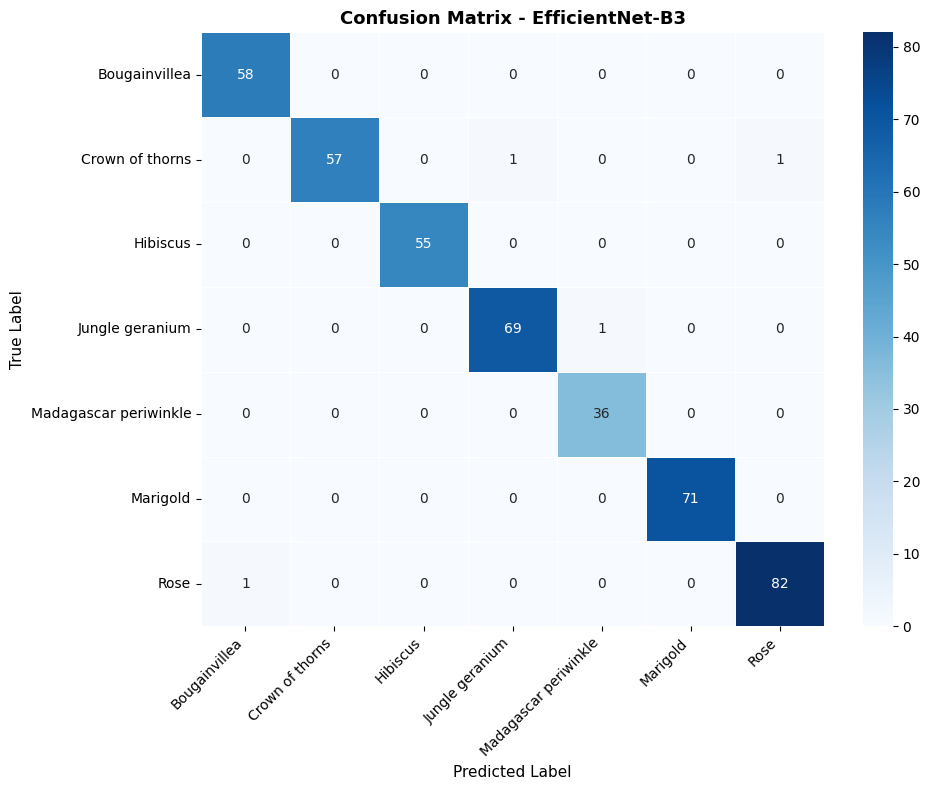

In [12]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                      RIGOROUS EVALUATION ON TEST SET                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def evaluate_model_on_test(model, test_loader, model_name, device):
    """Comprehensive evaluation with F1, Precision, Recall, and Confusion Matrix."""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            with autocast():
                outputs = model(images)
            
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = 100. * (all_preds == all_labels).sum() / len(all_labels)
    
    f1_macro = f1_score(all_labels, all_preds, average='macro') * 100
    f1_weighted = f1_score(all_labels, all_preds, average='weighted') * 100
    
    precision_macro = precision_score(all_labels, all_preds, average='macro') * 100
    precision_weighted = precision_score(all_labels, all_preds, average='weighted') * 100
    
    recall_macro = recall_score(all_labels, all_preds, average='macro') * 100
    recall_weighted = recall_score(all_labels, all_preds, average='weighted') * 100
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': precision_macro,
        'precision_weighted': precision_weighted,
        'recall_macro': recall_macro,
        'recall_weighted': recall_weighted,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }


def measure_inference_time(model, test_loader, device, num_batches=10):
    """Measure inference time per batch using CUDA events."""
    model.eval()
    
    # Warm-up
    for i, (images, _) in enumerate(test_loader):
        if i >= 3:
            break
        images = images.to(device)
        with torch.no_grad():
            _ = model(images)
    
    torch.cuda.synchronize()
    
    # Timing with CUDA events
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    
    times = []
    for i, (images, _) in enumerate(test_loader):
        if i >= num_batches:
            break
        images = images.to(device)
        
        start_event.record()
        with torch.no_grad():
            _ = model(images)
        end_event.record()
        
        torch.cuda.synchronize()
        times.append(start_event.elapsed_time(end_event))
    
    avg_time = np.mean(times)
    return avg_time  # milliseconds per batch


def plot_confusion_matrix(labels, preds, model_name):
    """Plot confusion matrix."""
    cm = confusion_matrix(labels, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


# Evaluate all models
all_models = {
    'MobileNetV3-Large': mobilenet_v3,
    'ResNeXt-50-32x4d': resnext50,
    'EfficientNet-B3': efficientnet_b3
}

results = {}
inference_times = {}

print("=" * 80)
print("TEST SET EVALUATION RESULTS")
print("=" * 80)

for model_name, model in all_models.items():
    print(f"\nEvaluating: {model_name}")
    
    # Evaluate
    result = evaluate_model_on_test(model, test_loader, model_name, DEVICE)
    results[model_name] = result
    
    # Measure inference time
    inf_time = measure_inference_time(model, test_loader, DEVICE)
    inference_times[model_name] = inf_time
    
    print(f"  Accuracy:           {result['accuracy']:.2f}%")
    print(f"  Macro F1:           {result['f1_macro']:.2f}%")
    print(f"  Weighted F1:        {result['f1_weighted']:.2f}%")
    print(f"  Macro Precision:    {result['precision_macro']:.2f}%")
    print(f"  Weighted Precision: {result['precision_weighted']:.2f}%")
    print(f"  Macro Recall:       {result['recall_macro']:.2f}%")
    print(f"  Weighted Recall:    {result['recall_weighted']:.2f}%")
    print(f"  Inference Time:     {inf_time:.2f} ms/batch")

print("\n" + "=" * 80)

# Summary table
print("\nSUMMARY TABLE")
print("-" * 90)
print(f"{'Model':<20} | {'Acc':>7} | {'F1-M':>7} | {'F1-W':>7} | {'Prec-M':>7} | {'Rec-M':>7} | {'Inf(ms)':>8}")
print("-" * 90)
for model_name in all_models.keys():
    r = results[model_name]
    print(f"{model_name:<20} | {r['accuracy']:>6.2f}% | {r['f1_macro']:>6.2f}% | "
          f"{r['f1_weighted']:>6.2f}% | {r['precision_macro']:>6.2f}% | "
          f"{r['recall_macro']:>6.2f}% | {inference_times[model_name]:>7.2f}")
print("-" * 90)

# Plot confusion matrices
for model_name, result in results.items():
    plot_confusion_matrix(result['labels'], result['predictions'], model_name)

ROBUSTNESS ANALYSIS - GAUSSIAN BLUR
Testing blur levels (kernel sizes): [5, 11, 21]

Testing: MobileNetV3-Large
  Clean:      99.07%
  Blur k= 5:  96.76% (drop: 2.31pp)
  Blur k=11:  81.25% (drop: 17.82pp)
  Blur k=21:  59.49% (drop: 39.58pp)

Testing: ResNeXt-50-32x4d
  Clean:      98.84%
  Blur k= 5:  97.22% (drop: 1.62pp)
  Blur k=11:  84.49% (drop: 14.35pp)
  Blur k=21:  54.17% (drop: 44.68pp)

Testing: EfficientNet-B3
  Clean:      98.84%
  Blur k= 5:  98.15% (drop: 0.69pp)
  Blur k=11:  92.82% (drop: 6.02pp)
  Blur k=21:  68.29% (drop: 30.56pp)



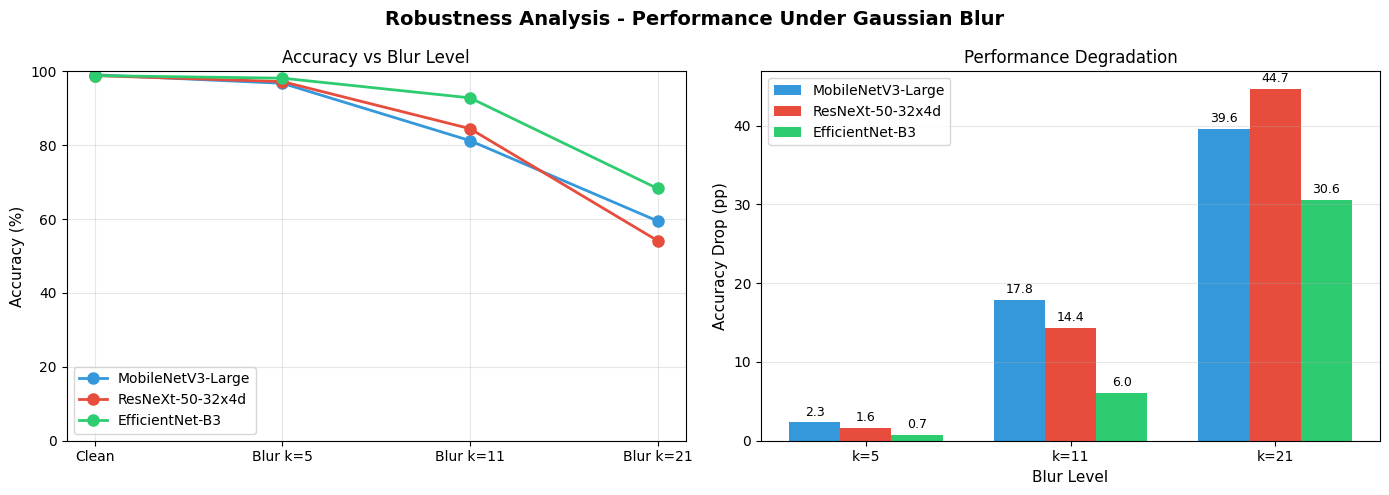

In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    ROBUSTNESS ANALYSIS - GAUSSIAN BLUR                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def create_blur_transform(kernel_size):
    """Create transform with Gaussian blur."""
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.GaussianBlur(kernel_size=kernel_size, sigma=(kernel_size/4, kernel_size/2)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def evaluate_robustness(model, model_name, blur_levels, device):
    """Evaluate model under increasing Gaussian blur levels."""
    results = {'clean': None}
    
    # Clean evaluation
    clean_dataset = FlowerDataset(test_paths, test_labels, transform=val_test_transform)
    clean_loader = DataLoader(clean_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in clean_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    results['clean'] = 100. * correct / total
    
    # Blur evaluations
    for blur_level in blur_levels:
        blur_transform = create_blur_transform(blur_level)
        blur_dataset = FlowerDataset(test_paths, test_labels, transform=blur_transform)
        blur_loader = DataLoader(blur_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in blur_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        results[f'blur_{blur_level}'] = 100. * correct / total
    
    return results


# Define 3 increasing levels of Gaussian Blur
BLUR_LEVELS = [5, 11, 21]  # Kernel sizes (must be odd)

print("=" * 70)
print("ROBUSTNESS ANALYSIS - GAUSSIAN BLUR")
print("=" * 70)
print(f"Testing blur levels (kernel sizes): {BLUR_LEVELS}")
print()

robustness_results = {}

for model_name, model in all_models.items():
    print(f"Testing: {model_name}")
    rob_result = evaluate_robustness(model, model_name, BLUR_LEVELS, DEVICE)
    robustness_results[model_name] = rob_result
    
    print(f"  Clean:      {rob_result['clean']:.2f}%")
    for blur_level in BLUR_LEVELS:
        acc = rob_result[f'blur_{blur_level}']
        drop = rob_result['clean'] - acc
        print(f"  Blur k={blur_level:>2}:  {acc:.2f}% (drop: {drop:.2f}pp)")
    print()

# Plot performance degradation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Robustness Analysis - Performance Under Gaussian Blur', fontsize=14, fontweight='bold')

x_labels = ['Clean'] + [f'Blur k={k}' for k in BLUR_LEVELS]
colors = ['#3498DB', '#E74C3C', '#2ECC71']

# Accuracy plot
for idx, (model_name, rob_result) in enumerate(robustness_results.items()):
    accuracies = [rob_result['clean']] + [rob_result[f'blur_{k}'] for k in BLUR_LEVELS]
    axes[0].plot(x_labels, accuracies, '-o', color=colors[idx], linewidth=2, 
                 markersize=8, label=model_name)

axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Accuracy vs Blur Level', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)

# Degradation plot
x_pos = np.arange(len(BLUR_LEVELS))
width = 0.25

for idx, (model_name, rob_result) in enumerate(robustness_results.items()):
    drops = [rob_result['clean'] - rob_result[f'blur_{k}'] for k in BLUR_LEVELS]
    bars = axes[1].bar(x_pos + idx*width, drops, width, label=model_name, color=colors[idx])
    for bar, drop in zip(bars, drops):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                     f'{drop:.1f}', ha='center', va='bottom', fontsize=9)

axes[1].set_ylabel('Accuracy Drop (pp)', fontsize=11)
axes[1].set_xlabel('Blur Level', fontsize=11)
axes[1].set_title('Performance Degradation', fontsize=12)
axes[1].set_xticks(x_pos + width)
axes[1].set_xticklabels([f'k={k}' for k in BLUR_LEVELS])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/robustness_blur_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

ERROR ANALYSIS - TOP 5 MISCLASSIFIED IMAGES PER MODEL

Analyzing: MobileNetV3-Large
  Found 4 high-confidence errors
    1. True: Rose                      | Pred: Bougainvillea             | Conf: 76.3%
    2. True: Jungle geranium           | Pred: Madagascar periwinkle     | Conf: 63.1%
    3. True: Rose                      | Pred: Bougainvillea             | Conf: 52.8%
    4. True: Crown of thorns           | Pred: Rose                      | Conf: 18.8%


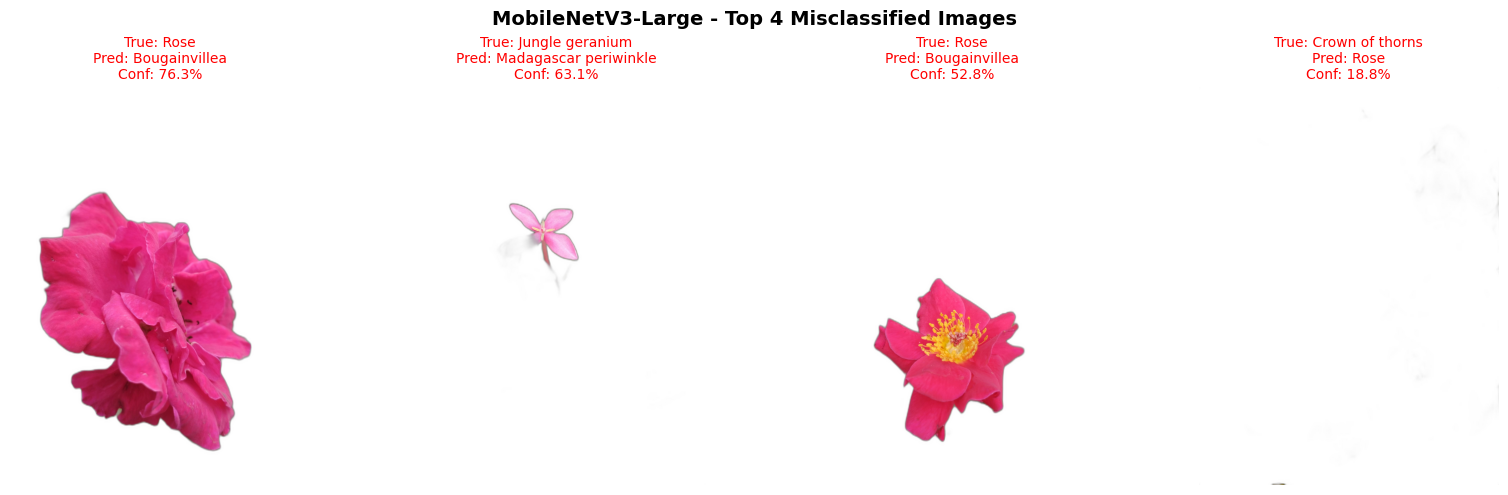


Analyzing: ResNeXt-50-32x4d
  Found 5 high-confidence errors
    1. True: Rose                      | Pred: Marigold                  | Conf: 65.2%
    2. True: Jungle geranium           | Pred: Madagascar periwinkle     | Conf: 37.6%
    3. True: Rose                      | Pred: Jungle geranium           | Conf: 37.4%
    4. True: Bougainvillea             | Pred: Crown of thorns           | Conf: 30.4%
    5. True: Crown of thorns           | Pred: Rose                      | Conf: 15.5%


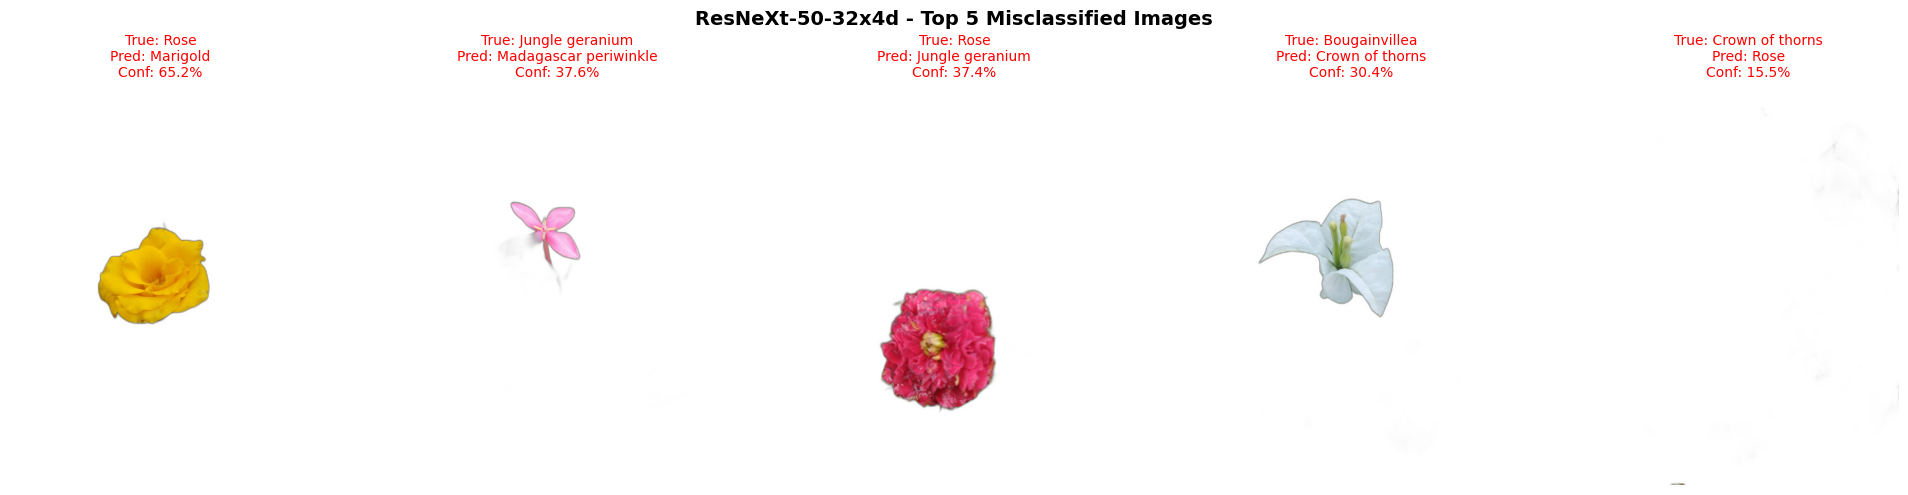


Analyzing: EfficientNet-B3
  Found 5 high-confidence errors
    1. True: Jungle geranium           | Pred: Madagascar periwinkle     | Conf: 97.7%
    2. True: Rose                      | Pred: Bougainvillea             | Conf: 95.4%
    3. True: Crown of thorns           | Pred: Rose                      | Conf: 64.3%
    4. True: Rose                      | Pred: Bougainvillea             | Conf: 48.7%
    5. True: Crown of thorns           | Pred: Jungle geranium           | Conf: 16.0%


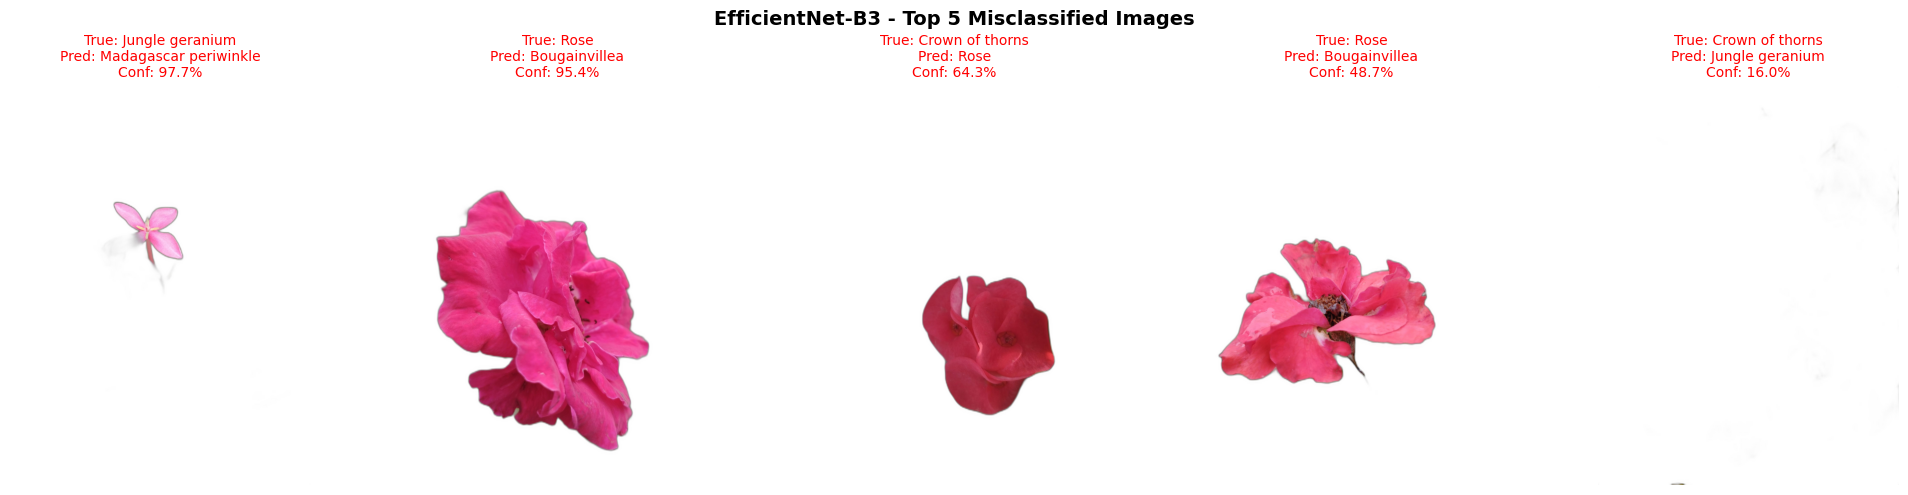

In [14]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    ERROR ANALYSIS - TOP MISCLASSIFIED IMAGES                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

def get_misclassified_images(model, test_paths, test_labels, transform, device, top_k=5):
    """Extract top-k misclassified images with highest confidence in wrong prediction."""
    model.eval()
    
    misclassified = []
    
    for img_path, true_label in zip(test_paths, test_labels):
        image = Image.open(img_path).convert('RGB')
        img_tensor = transform(image).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(img_tensor)
            probs = F.softmax(output, dim=1)
            conf, pred = probs.max(1)
            
            pred = pred.item()
            conf = conf.item()
            
            if pred != true_label:
                misclassified.append({
                    'path': img_path,
                    'true_label': true_label,
                    'pred_label': pred,
                    'confidence': conf * 100,  # Convert to percentage
                    'image': image
                })
    
    # Sort by confidence (highest confidence in wrong prediction first)
    misclassified.sort(key=lambda x: -x['confidence'])
    
    return misclassified[:top_k]


def plot_misclassified(misclassified, model_name, class_names):
    """Plot top misclassified images."""
    n = len(misclassified)
    if n == 0:
        print(f"No misclassified images for {model_name}!")
        return
    
    fig, axes = plt.subplots(1, n, figsize=(4*n, 5))
    fig.suptitle(f'{model_name} - Top {n} Misclassified Images', fontsize=14, fontweight='bold')
    
    if n == 1:
        axes = [axes]
    
    for idx, item in enumerate(misclassified):
        axes[idx].imshow(item['image'])
        axes[idx].set_title(
            f"True: {class_names[item['true_label']]}\n"
            f"Pred: {class_names[item['pred_label']]}\n"
            f"Conf: {item['confidence']:.1f}%",
            fontsize=10, color='red'
        )
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_misclassified.png', dpi=150, bbox_inches='tight')
    plt.show()


print("=" * 70)
print("ERROR ANALYSIS - TOP 5 MISCLASSIFIED IMAGES PER MODEL")
print("=" * 70)

for model_name, model in all_models.items():
    print(f"\nAnalyzing: {model_name}")
    
    misclassified = get_misclassified_images(
        model, test_paths, test_labels, val_test_transform, DEVICE, top_k=5
    )
    
    print(f"  Found {len(misclassified)} high-confidence errors")
    
    for i, item in enumerate(misclassified):
        print(f"    {i+1}. True: {CLASS_NAMES[item['true_label']]:25} | "
              f"Pred: {CLASS_NAMES[item['pred_label']]:25} | Conf: {item['confidence']:.1f}%")
    
    plot_misclassified(misclassified, model_name, CLASS_NAMES)

In [15]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                              FINAL SUMMARY                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print("\n" + "=" * 80)
print(" " * 25 + "FINAL RESULTS SUMMARY")
print("=" * 80)

# Create comprehensive results table
summary_data = []
for model_name in all_models.keys():
    r = results[model_name]
    model = all_models[model_name]
    params = count_parameters(model)
    
    summary_data.append({
        'Model': model_name,
        'Parameters': f'{params/1e6:.2f}M',
        'Accuracy (%)': f"{r['accuracy']:.2f}",
        'F1 Macro (%)': f"{r['f1_macro']:.2f}",
        'F1 Weighted (%)': f"{r['f1_weighted']:.2f}",
        'Precision (%)': f"{r['precision_macro']:.2f}",
        'Recall (%)': f"{r['recall_macro']:.2f}",
        'Inference (ms)': f"{inference_times[model_name]:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Best model
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
best_accuracy = results[best_model_name]['accuracy']

print("\n" + "-" * 80)
print(f"BEST MODEL: {best_model_name} with {best_accuracy:.2f}% Test Accuracy")
print("-" * 80)

# Robustness summary
print("\nROBUSTNESS SUMMARY (Accuracy Drop at Blur k=21):")
print("-" * 50)
for model_name, rob_result in robustness_results.items():
    clean_acc = rob_result['clean']
    blur_acc = rob_result['blur_21']
    drop = clean_acc - blur_acc
    print(f"  {model_name:<20}: {drop:.2f}pp drop")

print("\n" + "=" * 80)
print(" " * 20 + "PIPELINE EXECUTION COMPLETE")
print("=" * 80)

# Save final results to JSON
import json

final_results = {
    'models': {},
    'robustness': robustness_results,
    'config': {
        'batch_size': BATCH_SIZE,
        'epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'image_size': IMG_SIZE,
        'seed': SEED
    }
}

for model_name in all_models.keys():
    r = results[model_name]
    final_results['models'][model_name] = {
        'accuracy': float(r['accuracy']),
        'f1_macro': float(r['f1_macro']),
        'f1_weighted': float(r['f1_weighted']),
        'precision_macro': float(r['precision_macro']),
        'recall_macro': float(r['recall_macro']),
        'inference_time_ms': float(inference_times[model_name])
    }

with open(f'{OUTPUT_DIR}/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print(f"\nResults saved to: {OUTPUT_DIR}/final_results.json")


                         FINAL RESULTS SUMMARY
            Model Parameters Accuracy (%) F1 Macro (%) F1 Weighted (%) Precision (%) Recall (%) Inference (ms)
MobileNetV3-Large      4.21M        99.07        99.08           99.08         98.96      99.21          14.85
 ResNeXt-50-32x4d     22.99M        98.84        98.87           98.84         98.80      98.96          68.46
  EfficientNet-B3     10.71M        99.07        99.06           99.07         99.00      99.14          47.83

--------------------------------------------------------------------------------
BEST MODEL: MobileNetV3-Large with 99.07% Test Accuracy
--------------------------------------------------------------------------------

ROBUSTNESS SUMMARY (Accuracy Drop at Blur k=21):
--------------------------------------------------
  MobileNetV3-Large   : 39.58pp drop
  ResNeXt-50-32x4d    : 44.68pp drop
  EfficientNet-B3     : 30.56pp drop

                    PIPELINE EXECUTION COMPLETE

Results saved to: /kaggle/w